# Cross-cohort 16S meta-analysis

The single-cohort DA benchmark ([t_16s_da_comparison](t_16s_da_comparison.ipynb))
shows that Wilcoxon, DESeq2 and ANCOM-BC often disagree on which genera
separate two groups. [Nearing *et al.* 2022](https://www.nature.com/articles/s41467-022-28034-z)
put numbers on that by benchmarking 14 DA methods over 38 16S studies and found the
*between-dataset* signal is far more reproducible than any single-dataset
verdict — i.e. the right way to learn a robust microbiome biomarker is to
pool effect sizes from several independent cohorts.

This notebook walks through that pooling with two new `ov.micro` APIs:

| API | What it does |
|---|---|
| `ov.micro.combine_studies([a, b, c], rank='genus')` | Concatenate per-study AnnDatas onto a shared feature axis (union of taxa, zero-fill absent) with an `obs['study']` label — the "mega-analysis" input. |
| `ov.micro.meta_da([a, b, c], group_key='disease', method='deseq2')` | Run the chosen DA method **on each study separately**, then combine per-feature log-fold-changes by inverse-variance-weighted random-effects meta-analysis (DerSimonian-Laird), with Cochran's Q / I² heterogeneity. |

For pedagogical clarity we start from a synthetic 3-cohort simulation where
the ground truth is known — the CASE group has ~5× more counts of two
"disease-marker" genera, embedded in per-cohort batch noise on the other
features. The same pattern scales to real public cohorts (see the closing
section).

## 1. Setup + simulate three cohorts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from scipy import sparse

import omicverse as ov
ov.plot_set()
print('omicverse:', ov.__version__)

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse: 2.1.2rc1


Each cohort has 20 samples (10 CTRL + 10 CASE), 30 ASVs that collapse
onto 18 genera.

* Features `g_disease_{1,2}` are the **planted signal** — CASE samples get ~5× more counts in every cohort.
* Features `g_cohort_specific_{A,B,C}_{1,2}` are **cohort batch markers** — only one cohort has them (imagine primer / region / reagent differences).
* Remaining features are shared noise.

The ground-truth DA signal is therefore exactly 2 genera; any method that
ranks more than a handful of shared "noise" genera above these two is
picking up per-cohort batch effects.

In [2]:
def simulate_cohort(name, seed, n_per_group=10, n_features=30,
                    disease_multiplier=5.0, cohort_batch_mean=1.0):
    rng = np.random.default_rng(seed)
    n = 2 * n_per_group
    # base counts: negative-binomial-like with cohort-specific mean scaling
    X = rng.negative_binomial(n=5, p=0.05, size=(n, n_features)).astype(np.int32)
    X = (X * cohort_batch_mean).astype(np.int32)
    # plant a consistent disease effect on features 0 and 1
    X[n_per_group:, 0] = (X[n_per_group:, 0] * disease_multiplier).astype(np.int32)
    X[n_per_group:, 1] = (X[n_per_group:, 1] * disease_multiplier).astype(np.int32)
    # pick taxonomy labels: shared noise + 2 planted + 2 cohort-specific
    genera = []
    for i in range(n_features):
        if i in (0, 1):
            genera.append(f'g_disease_{i+1}')
        elif i in (2, 3):
            genera.append(f'g_cohort_{name}_{i-1}')
        else:
            genera.append(f'g_shared_{i}')
    obs = pd.DataFrame({
        'disease': ['CTRL'] * n_per_group + ['CASE'] * n_per_group,
    }, index=[f'{name}_S{i}' for i in range(n)])
    var = pd.DataFrame({
        'genus':   genera,
        'domain':  ['Bacteria'] * n_features,
        'phylum':  [''] * n_features,
        'class':   [''] * n_features,
        'order':   [''] * n_features,
        'family':  [''] * n_features,
        'species': [''] * n_features,
    }, index=[f'{name}_ASV{i}' for i in range(n_features)])
    return ad.AnnData(X=sparse.csr_matrix(X), obs=obs, var=var)


adata_A = simulate_cohort('A', seed=0, cohort_batch_mean=1.0)
adata_B = simulate_cohort('B', seed=1, cohort_batch_mean=2.5)
adata_C = simulate_cohort('C', seed=2, cohort_batch_mean=0.4)

print('cohort A:', adata_A.shape, 'mean total counts =',
      int(adata_A.X.sum(axis=1).mean()))
print('cohort B:', adata_B.shape, 'mean total counts =',
      int(adata_B.X.sum(axis=1).mean()))
print('cohort C:', adata_C.shape, 'mean total counts =',
      int(adata_C.X.sum(axis=1).mean()))

cohort A: (20, 30) mean total counts = 3197
cohort B: (20, 30) mean total counts = 7893
cohort C: (20, 30) mean total counts = 1283


## 2. `combine_studies` — mega-analysis table

The simplest cross-cohort play is: stack all samples into one matrix,
label them by study, and treat `study` as a batch covariate in your
favourite DA model. `combine_studies` does the bookkeeping — collapse to
a shared rank, take the union of taxa, and zero-fill cells for taxa that
didn't appear in a given study (so the cohort-specific genera above
*do* appear, just zero outside their cohort).

In [3]:
adata_all = ov.micro.combine_studies(
    [adata_A, adata_B, adata_C],
    study_names=['cohort_A', 'cohort_B', 'cohort_C'],
    rank='genus',
)
print('combined shape (samples × genera):', adata_all.shape)
print('study breakdown:\n', adata_all.obs['study'].value_counts())
print('disease breakdown:\n', adata_all.obs['disease'].value_counts())
print()
print('example zero-fill — cohort_B_1/2 appears only in cohort B:')
cohort_b_feat = 'g_cohort_B_1'
print(f'  counts of {cohort_b_feat} per study:')
X_dense = adata_all.X.toarray()
feat_idx = adata_all.var_names.get_loc(cohort_b_feat)
for study_name in ['cohort_A', 'cohort_B', 'cohort_C']:
    mask = adata_all.obs['study'].values == study_name
    print(f'    {study_name}: total = {int(X_dense[mask, feat_idx].sum()):d}')

combined shape (samples × genera): (60, 34)
study breakdown:
 study
cohort_A    20
cohort_B    20
cohort_C    20
Name: count, dtype: int64
disease breakdown:
 disease
CTRL    30
CASE    30
Name: count, dtype: int64

example zero-fill — cohort_B_1/2 appears only in cohort B:
  counts of g_cohort_B_1 per study:
    cohort_A: total = 0
    cohort_B: total = 4060
    cohort_C: total = 0


## 3. Why naive pooling fails — the study effect dominates the PCA

Before running any meta-analysis we should motivate why it's needed.
Embed the combined matrix with a simple Bray-Curtis PCoA and colour by
cohort vs disease — if the cohorts separate cleanly and CASE/CTRL are
intermixed within each cohort, that's the "batch effect" you'd confound
any naive DA test with.

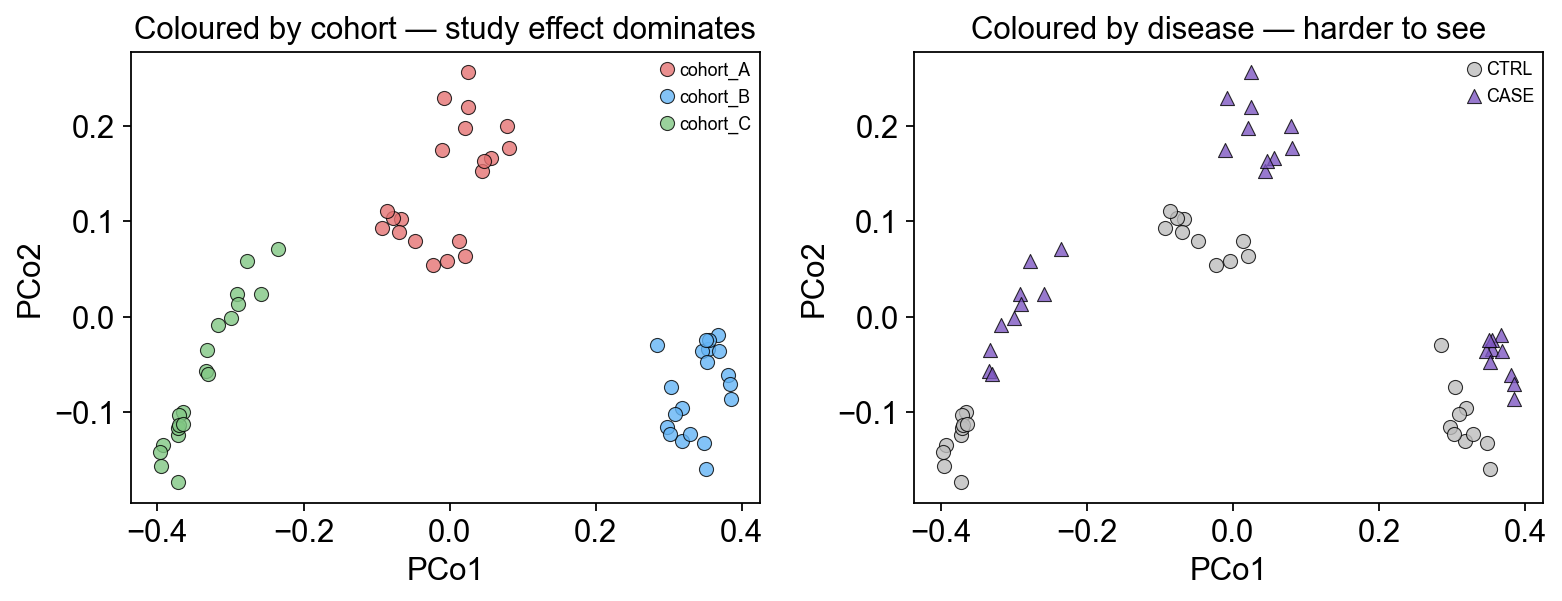

In [4]:
ov.micro.Beta(adata_all).run(metric='braycurtis', rarefy=False)
coords = ov.micro.Ordinate(adata_all, dist_key='braycurtis').pcoa(n=2)
# .pcoa returns a DataFrame — convert to ndarray for bool-mask indexing.
coords = np.asarray(coords)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
palette = {'cohort_A': '#E57373', 'cohort_B': '#64B5F6', 'cohort_C': '#81C784'}
for study_name, color in palette.items():
    mask = adata_all.obs['study'].values == study_name
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    s=40, alpha=0.8, c=color, label=study_name,
                    edgecolors='k', linewidths=0.5)
axes[0].set_xlabel('PCo1'); axes[0].set_ylabel('PCo2')
axes[0].set_title('Coloured by cohort — study effect dominates')
axes[0].legend(loc='best', fontsize=8)

for grp, marker in (('CTRL', 'o'), ('CASE', '^')):
    mask = adata_all.obs['disease'].values == grp
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    s=40, alpha=0.8, marker=marker, label=grp,
                    edgecolors='k', linewidths=0.5,
                    c='#7E57C2' if grp == 'CASE' else '#BDBDBD')
axes[1].set_xlabel('PCo1'); axes[1].set_ylabel('PCo2')
axes[1].set_title('Coloured by disease — harder to see')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout(); plt.show()

## 4. Per-study DA — each cohort sees a different top-hit list

Run the same DESeq2 DA on each cohort separately and compare the top-5
hits. The planted `g_disease_1 / 2` features should be in every cohort's
top-5, but cohort-specific genera and noise will also bubble up.

In [5]:
per_study_hits = {}
for name, a in [('cohort_A', adata_A),
                ('cohort_B', adata_B),
                ('cohort_C', adata_C)]:
    a_g = ov.micro.collapse_taxa(a, rank='genus')
    res = ov.micro.DA(a_g).deseq2(
        group_key='disease', group_a='CTRL', group_b='CASE',
        min_prevalence=0.1,
    )
    per_study_hits[name] = res.head(5)['feature'].tolist()
    print(f'{name} top 5 by p_value:', per_study_hits[name])

planted = {'g_disease_1', 'g_disease_2'}
print()
print('planted signal found in every cohort top-5?',
      all(planted <= set(h) for h in per_study_hits.values()))
print('overlap of top-5 across the 3 cohorts:',
      set.intersection(*[set(h) for h in per_study_hits.values()]))

cohort_A top 5 by p_value: ['g_disease_2', 'g_disease_1', 'g_shared_17', 'g_shared_10', 'g_shared_19']
cohort_B top 5 by p_value: ['g_disease_2', 'g_disease_1', 'g_shared_6', 'g_shared_16', 'g_shared_9']


cohort_C top 5 by p_value: ['g_disease_2', 'g_disease_1', 'g_shared_7', 'g_shared_20', 'g_shared_27']

planted signal found in every cohort top-5? True
overlap of top-5 across the 3 cohorts: {'g_disease_2', 'g_disease_1'}


## 5. `meta_da` — inverse-variance-weighted random-effects combine

`meta_da` runs DA on each cohort (same call as section 4 internally) and
combines the per-feature log2 fold-changes with DerSimonian-Laird
random-effects meta-analysis. The output carries:

- `combined_lfc` — the pooled log2 fold-change
- `combined_se`  — its standard error
- `z`, `p_value`, `fdr_bh` — Wald test + BH correction
- `n_studies` — cohorts contributing to this feature (≥ 1)
- `Q`, `I2`, `tau2` — between-study heterogeneity

In [6]:
meta = ov.micro.meta_da(
    [adata_A, adata_B, adata_C],
    study_names=['cohort_A', 'cohort_B', 'cohort_C'],
    group_key='disease', group_a='CTRL', group_b='CASE',
    method='deseq2',
    rank='genus',
    min_prevalence=0.1,
    combine='random_effects',
)
print('features tested cross-cohort:', len(meta))
print('significant @ FDR 0.05:',
      int((meta['fdr_bh'] < 0.05).sum()))

cols = ['feature', 'combined_lfc', 'combined_se', 'z',
        'p_value', 'fdr_bh', 'n_studies', 'I2']
meta[cols].head(10)

features tested cross-cohort: 34
significant @ FDR 0.05: 2


        feature  combined_lfc  combined_se          z   p_value    fdr_bh  \
0   g_disease_2      2.636974     0.170717  15.446472  0.000000  0.000000   
1   g_disease_1      2.130856     0.176548  12.069575  0.000000  0.000000   
2   g_shared_16     -0.347366     0.155909  -2.228002  0.025880  0.293311   
3   g_shared_17     -0.316652     0.163069  -1.941832  0.052157  0.366021   
4   g_shared_19     -0.327073     0.169623  -1.928229  0.053827  0.366021   
5    g_shared_9     -0.302774     0.168061  -1.801574  0.071612  0.405804   
6  g_cohort_B_1      0.509131     0.317278   1.604687  0.108563  0.518789   
7   g_shared_22     -0.302948     0.195937  -1.546151  0.122068  0.518789   
8   g_shared_25     -0.180131     0.148143  -1.215926  0.224013  0.796178   
9   g_shared_29      0.203479     0.171036   1.189685  0.234170  0.796178   

   n_studies   I2  
0          3  0.0  
1          3  0.0  
2          3  0.0  
3          3  0.0  
4          3  0.0  
5          3  0.0  
6          1

## 6. Did we recover the planted signal?

Visualise the top-10 meta-DA hits with their combined log2FC and 95% CI.
The two planted features (`g_disease_1/2`) should top the ranking;
shared noise and cohort-specific features sit near zero or inside the
non-significant band.

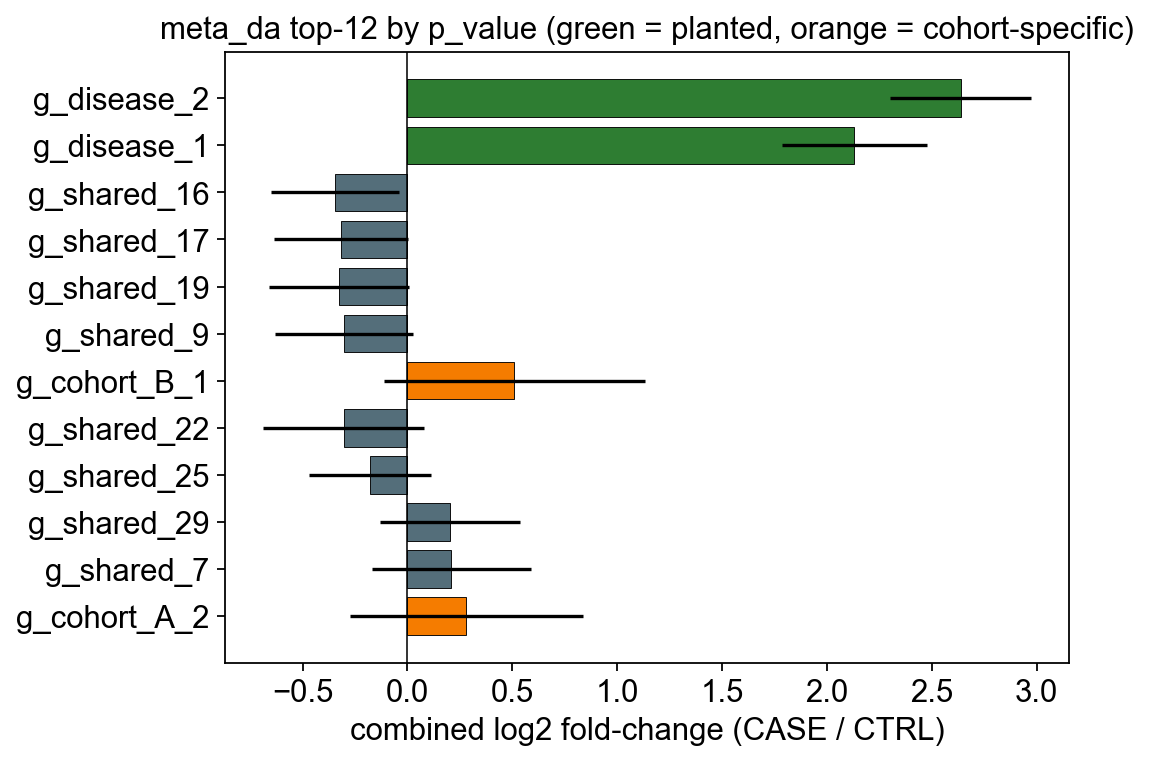

In [7]:
top = meta.head(12).copy().iloc[::-1]   # highest p at top → reversed for plot
colors = ['#2E7D32' if f.startswith('g_disease_')
          else '#F57C00' if f.startswith('g_cohort_')
          else '#546E7A' for f in top['feature']]
ci = 1.96 * top['combined_se'].values

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top['feature'], top['combined_lfc'],
        xerr=ci, color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('combined log2 fold-change (CASE / CTRL)')
ax.set_title('meta_da top-12 by p_value (green = planted, orange = cohort-specific)')
plt.tight_layout(); plt.show()

## 7. Heterogeneity diagnostics — which hits are consistent?

`I²` (Higgins 2003) summarises what fraction of the variance in per-study
effects is between-study rather than within-study sampling noise. Rule
of thumb: I² < 25% is low heterogeneity, I² > 75% is high. For a
biomarker paper you want the significant hits to also have low I².

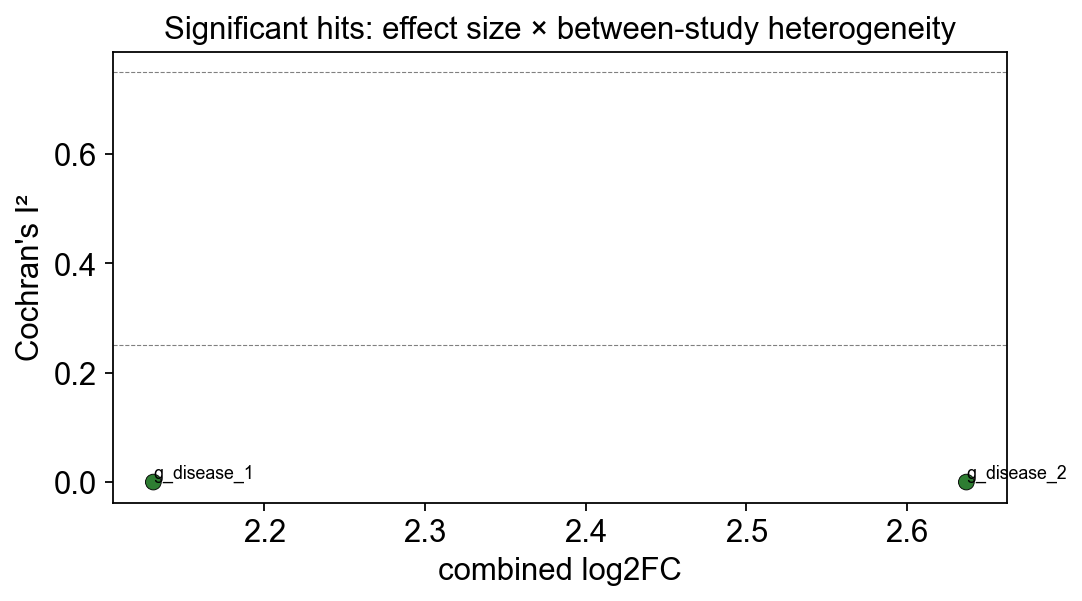

In [8]:
sig = meta[meta['fdr_bh'] < 0.05].copy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sig['combined_lfc'], sig['I2'],
           s=50, c=['#2E7D32' if f.startswith('g_disease_')
                    else '#F57C00' if f.startswith('g_cohort_')
                    else '#546E7A' for f in sig['feature']],
           edgecolors='k', linewidths=0.4)
for _, row in sig.iterrows():
    if row['feature'].startswith('g_disease_') or row['I2'] > 0.5:
        ax.annotate(row['feature'],
                    (row['combined_lfc'], row['I2']),
                    fontsize=8, ha='left', va='bottom')
ax.axhline(0.25, color='grey', lw=0.5, ls='--')
ax.axhline(0.75, color='grey', lw=0.5, ls='--')
ax.set_xlabel('combined log2FC')
ax.set_ylabel("Cochran's I²")
ax.set_title('Significant hits: effect size × between-study heterogeneity')
plt.tight_layout(); plt.show()

## 8. Swap the DA backend — the meta-analysis framework is method-agnostic

`meta_da(..., method='wilcoxon' | 'deseq2' | 'ancombc')` reuses the same
inverse-variance combine regardless of backend — so you can check
whether the meta-analysis verdict itself depends on the underlying
single-cohort method. With a strong planted signal, all three should
flag the same two features; with a weak signal they may disagree,
and the method-agnostic intersection is your robust biomarker set.

In [9]:
results = {}
for method in ['wilcoxon', 'deseq2', 'ancombc']:
    results[method] = ov.micro.meta_da(
        [adata_A, adata_B, adata_C],
        study_names=['cohort_A', 'cohort_B', 'cohort_C'],
        group_key='disease', group_a='CTRL', group_b='CASE',
        method=method,
        rank='genus', min_prevalence=0.1,
    )

summary = pd.DataFrame({
    'n_features_tested': {m: len(r) for m, r in results.items()},
    'n_sig_fdr_0.05':    {m: int((r['fdr_bh'] < 0.05).sum())
                           for m, r in results.items()},
    'planted_1_rank':    {m: int(r.index[r['feature'] == 'g_disease_1'].tolist()[0]) + 1
                           if (r['feature'] == 'g_disease_1').any() else -1
                           for m, r in results.items()},
    'planted_2_rank':    {m: int(r.index[r['feature'] == 'g_disease_2'].tolist()[0]) + 1
                           if (r['feature'] == 'g_disease_2').any() else -1
                           for m, r in results.items()},
})
summary

          n_features_tested  n_sig_fdr_0.05  planted_1_rank  planted_2_rank
wilcoxon                 34               2               2               1
deseq2                   34               2               2               1
ancombc                  34               2               2               1

## 9. Scaling to real public cohorts

The same recipe applies verbatim to published 16S studies. The canonical
demonstration is the 5-cohort colorectal-cancer 16S meta-analysis by
[Thomas *et al.* 2019](https://www.nature.com/articles/s41591-019-0405-7)
(Zeller, Feng, Vogtmann, Yu, Thomas) — once each study is loaded into an
AnnData (with shared `obs['condition']` ∈ {CTRL, CRC} and arbitrary
other covariates), the call is identical:

```python
crc_studies = [ad_zeller, ad_feng, ad_vogtmann, ad_yu, ad_thomas]
adata_all   = ov.micro.combine_studies(crc_studies, rank='genus')
meta        = ov.micro.meta_da(
    crc_studies, group_key='condition', group_a='CTRL', group_b='CRC',
    method='deseq2', rank='genus', combine='random_effects',
)
```

For 16S datasets with only relative-abundance tables available,
use `method='wilcoxon'` (no SE information, but `meta_da` falls back to
the empirical between-study SE). For count-preserving pipelines
(DADA2 → AnnData, our own `amplicon_16s_pipeline`) either `deseq2` or
`ancombc` give sharper answers.

## Recipe summary

1. **Harmonise taxonomy** → `ov.micro.combine_studies(studies, rank='genus')`
2. **Pre-flight diagnostic** → `Beta` + `Ordinate.pcoa` coloured by cohort (make sure study effects aren't *entirely* separable)
3. **Meta-DA** → `ov.micro.meta_da(studies, method='deseq2', combine='random_effects')`
4. **Filter by heterogeneity** → keep hits with `I² < 0.5` and `fdr_bh < 0.05`
5. **Sanity-check by swapping methods** → `method='ancombc'` / `'wilcoxon'`; intersect the significant sets

## References

- Nearing, J. T., Douglas, G. M., Hayes, M. G., MacDonald, J., Desai, D. K., Allward, N., Jones, C. M. A., Wright, R. J., Dhanani, A. S., Comeau, A. M., & Langille, M. G. I. (2022). Microbiome differential abundance methods produce different results across 38 datasets. *Nature Communications*, 13(1), 342. <https://doi.org/10.1038/s41467-022-28034-z>
- Thomas, A. M., Manghi, P., Asnicar, F., Pasolli, E., Armanini, F., Zolfo, M., Beghini, F., Manara, S., Karcher, N., Pozzi, C., … Segata, N. (2019). Metagenomic analysis of colorectal cancer datasets identifies cross-cohort microbial diagnostic signatures and a link with choline degradation. *Nature Medicine*, 25(4), 667–678. <https://doi.org/10.1038/s41591-019-0405-7>
- DerSimonian, R., & Laird, N. (1986). Meta-analysis in clinical trials. *Controlled Clinical Trials*, 7(3), 177–188. <https://doi.org/10.1016/0197-2456(86)90046-2>
- Higgins, J. P. T., Thompson, S. G., Deeks, J. J., & Altman, D. G. (2003). Measuring inconsistency in meta-analyses. *BMJ*, 327(7414), 557–560. <https://doi.org/10.1136/bmj.327.7414.557>
- Ma, S., Ren, B., Mallick, H., Moon, Y. S., Schwager, E., Maharjan, S., Tickle, T. L., Lu, Y., Carmody, R. N., Franzosa, E. A., Janson, L., & Huttenhower, C. (2022). A statistical model for describing and simulating microbial community profiles. *PLOS Computational Biology*, 18(9), e1010356 (MMUPHin / SparseDOSSA2). <https://doi.org/10.1371/journal.pcbi.1010356>